# Laboration 2: Modelling Wine Quality

**Name(s):**
**Date:**

Follow `instructions.md` for the full task description, timing, and the
Checkpoint questions. This notebook is your **working notebook** — light
comments are enough here; your answers to the Checkpoints go on a
**separate answer sheet**, not in this file.

Sections below are labelled to match the instructions exactly
(Step 1 / Step 2 / Step 3 / Step 4) so you can move through the 4-hour
session without hunting for where each part goes.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split, cross_val_score, KFold, cross_val_predict
from sklearn.metrics import (mean_squared_error, r2_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              accuracy_score)

sns.set_theme(style='ticks', palette='colorblind')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

RANDOM_STATE = 42  # keep this fixed so your results are reproducible

---
## Step 1 — Data Curation (0:00–0:30)

- [ ] Load the data, check shape / columns / dtypes
- [ ] Check for missing values
- [ ] Check for duplicate rows — look closely before deciding what to do (→ **Checkpoint 1a**)
- [ ] Look at the distribution of `quality` (→ **Checkpoint 1b**)
- [ ] Standardise the 11 predictor variables, ready for Step 2

In [3]:
# Load the data (red wine is the primary dataset for Steps 1-3)

# Download the files from github if you are working on uppmax/colab
!wget https://raw.githubusercontent.com/peterbmob/1kb570_2026/refs/heads/main/Labs/02_modelling_wine_quality/winequality-red.csv
!wget https://raw.githubusercontent.com/peterbmob/1kb570_2026/refs/heads/main/Labs/02_modelling_wine_quality/winequality-white.csv

df = pd.read_csv('winequality-red.csv', sep=';')
df.head()

--2026-09-23 11:30:59--  https://raw.githubusercontent.com/peterbmob/1kb570_2026/refs/heads/main/Labs/02_modelling_wine_quality/winequality-red.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 84199 (82K) [text/plain]
Saving to: ‘winequality-red.csv’

winequality-red.csv 100%[===================>]  82.23K  --.-KB/s    in 0.02s   

2026-09-23 11:30:59 (3.35 MB/s) - ‘winequality-red.csv’ saved [84199/84199]

--2026-09-23 11:30:59--  https://raw.githubusercontent.com/peterbmob/1kb570_2026/refs/heads/main/Labs/02_modelling_wine_quality/winequality-white.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
# TODO: check the shape, column names, and dtypes
print(df.shape)
print(df.columns)
print(df.dtypes)



(1599, 12)
Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object


In [5]:
# TODO: check for missing values

df.isnull().sum()


,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [6]:
# TODO: check for duplicate rows (df.duplicated())
# How many are there? What will you do about them, and why?
# -- write your reasoning on the answer sheet (Checkpoint 1a), not here

print(df.duplicated().sum())
df = df.drop_duplicates()

print(df.duplicated().sum())



240
0


In [7]:
# TODO: look at the distribution of `quality`
# (value_counts() and/or a histogram are both fine)
print(df['quality'].value_counts().sort_index())


quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64


In [8]:
# TODO: separate predictors (X, the 11 physicochemical columns) from the
# response (y = quality), then standardise X ready for PCA.
# Hint: StandardScaler().fit_transform(X) -- do NOT standardise quality itself.
y = df['quality']

x_df = df.drop('quality', axis=1)

x = StandardScaler().fit_transform(x_df)


---
## Step 2 — PCA (0:30–1:30)

Fit PCA on the **standardised predictors only** — `quality` is the response
you are trying to predict, not a predictor, so it must not go into the PCA.

- [ ] Fit PCA, produce a scree plot (individual + cumulative variance)
- [ ] Decide how many components to keep, and by which criterion (→ **Checkpoint 2a**)
- [ ] Score plot (PC1 vs PC2), coloured by `quality` (→ **Checkpoint 2b**)
- [ ] Loading plot for the same two components (→ **Checkpoint 2c**)

In [9]:
# TODO: fit PCA on the standardised predictor matrix
X_scaled_sklearn = StandardScaler().fit_transform(x)
pca_sklearn = PCA()
scores_sklearn = pca_sklearn.fit_transform(X_scaled_sklearn)
print(pca_sklearn.explained_variance_ratio_.round(3)[0:6].sum())


0.856


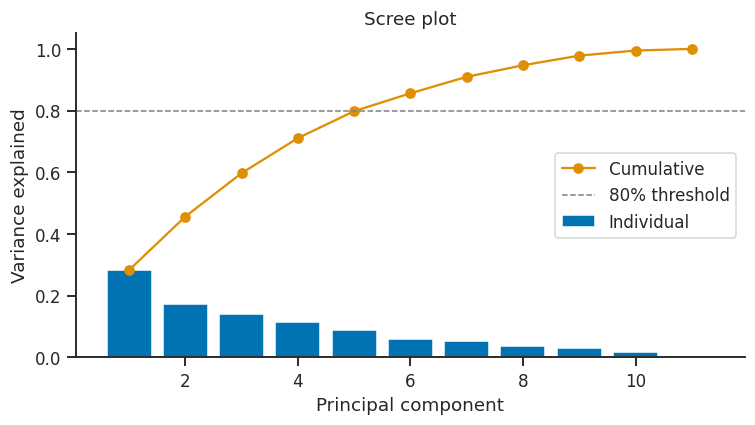

In [10]:
# TODO: scree plot -- individual explained variance (bars) and
# cumulative explained variance (line), same style as the course notebooks

fig, ax = plt.subplots(figsize=(7, 4))
n_show = 11
ax.bar(range(1, n_show+1), pca_sklearn.explained_variance_ratio_[:n_show],
       color=sns.color_palette('colorblind')[0], label='Individual')
ax.plot(range(1, n_show+1), np.cumsum(pca_sklearn.explained_variance_ratio_[:n_show]),
        'o-', color=sns.color_palette('colorblind')[1], label='Cumulative')
ax.axhline(0.80, color='gray', ls='--', lw=1, label='80% threshold')
ax.set_xlabel('Principal component'); ax.set_ylabel('Variance explained')
ax.set_title('Scree plot')
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

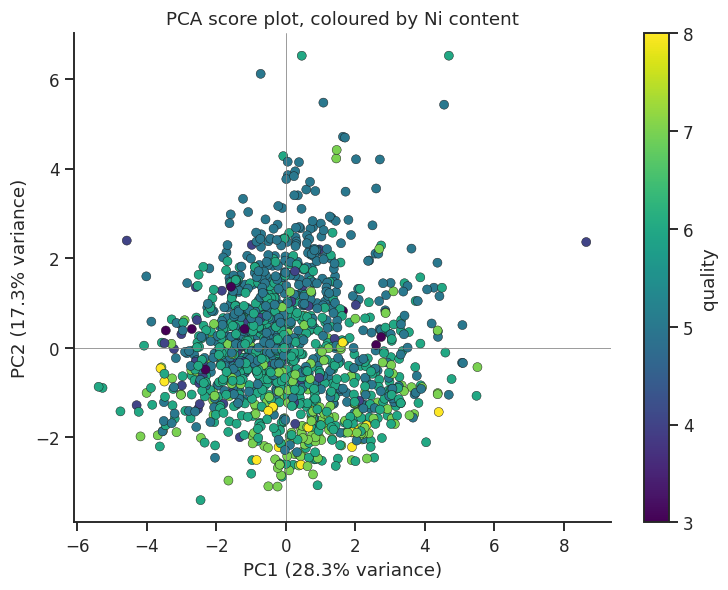

In [11]:
# TODO: score plot -- PC1 vs PC2, colour the points by `quality`
# (a continuous colourmap, e.g. cmap='viridis', works well for an ordinal 0-10 score)

df_scores = pd.DataFrame(scores_sklearn[:, :3], columns=['PC1', 'PC2', 'PC3'])
df_scores['quality'] = df['quality'].values

fig, ax = plt.subplots(figsize=(7, 5.5))
sc = ax.scatter(df_scores['PC1'], df_scores['PC2'], c=df_scores['quality'],
                 cmap='viridis', s=35, edgecolor='k', linewidth=0.3)
ax.set_xlabel(f'PC1 ({pca_sklearn.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca_sklearn.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('PCA score plot, coloured by Ni content')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
plt.colorbar(sc, label='quality')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

                       PC1   PC2
pH                   -0.44  0.00
volatile acidity     -0.24  0.28
alcohol              -0.12 -0.40
free sulfur dioxide  -0.02  0.51
total sulfur dioxide  0.04  0.58
residual sugar        0.13  0.24
chlorides             0.21  0.13
sulphates             0.25 -0.05
density               0.39  0.23
citric acid           0.46 -0.16
fixed acidity         0.49 -0.11


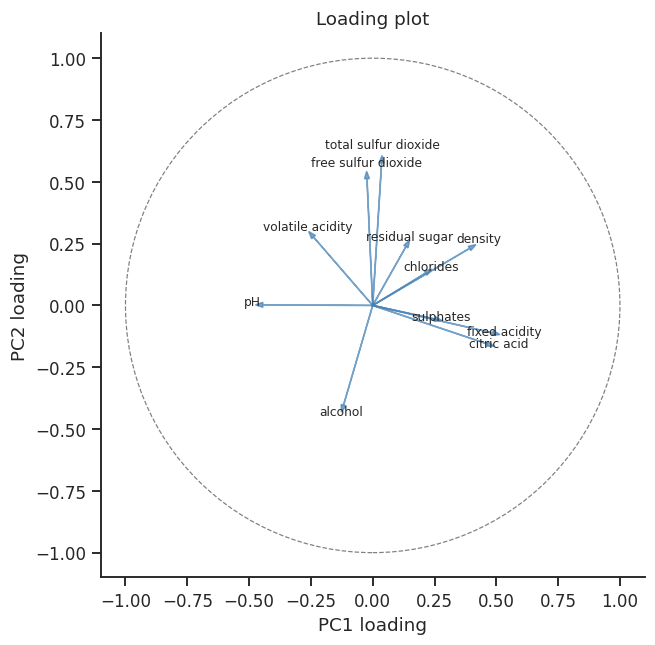

In [12]:
# TODO: loading plot for PC1 vs PC2 -- which variables have the largest
# loadings, and in which direction?

loadings_df = pd.DataFrame(pca_sklearn.components_[:2].T, index = x_df.columns, columns=['PC1', 'PC2'])
print(loadings_df.round(2).sort_values('PC1'))

fig, ax = plt.subplots(figsize=(7, 6))
for var in x_df.columns:
    x_co, y_co = loadings_df.loc[var, 'PC1'], loadings_df.loc[var, 'PC2']
    ax.arrow(0, 0, x_co, y_co, head_width=0.02, color='steelblue', alpha=0.7)
    ax.text(x_co*1.1, y_co*1.1, var, fontsize=8, ha='center')
circle = plt.Circle((0, 0), 1, fill=False, color='gray', ls='--', lw=0.8)
ax.add_patch(circle)
ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
ax.set_xlabel('PC1 loading'); ax.set_ylabel('PC2 loading')
ax.set_aspect('equal')
ax.set_title('Loading plot')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

---
## Step 3 — Model Quality: PLS *and* LDA (1:30–3:00)

Build **both** models today (see `instructions.md` for the full reasoning) —
not a choice between them. Keep both sections; do not delete either.

- [ ] Fit both models with a proper train/test split (or CV)
- [ ] Report validated performance for each, not training-set fit (→ **Checkpoints 3a, 3b**)
- [ ] Compare the two models (→ **Checkpoint 3c**)
- [ ] Identify which variable(s) matter most to each model (→ **Checkpoint 3d**)

### PLS (quality treated as continuous)

In [13]:
# TODO: train/test split (or set up cross-validation)
x = StandardScaler().fit_transform(x_df)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=0)
print(f'Train: {X_train.shape[0]}, Test: {X_test.shape[0]}')


Train: 1019, Test: 340


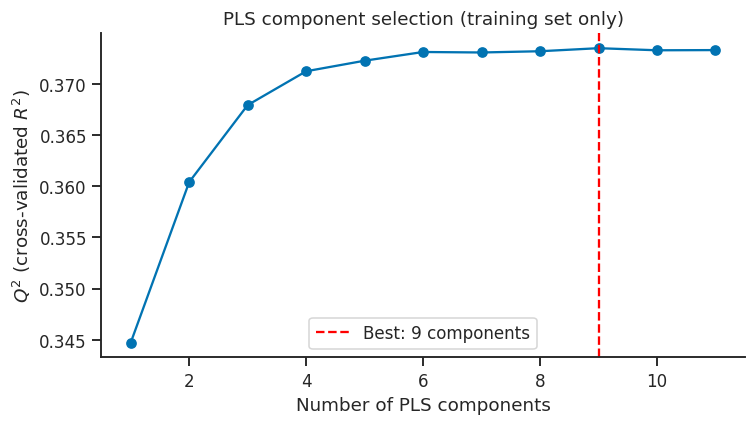

PLSRegression(n_components=11, scale=False)

In [14]:
# TODO: fit PLSRegression; choose the number of latent variables using
# cross-validated RMSE or Q^2, not the training-set fit alone

kf = KFold(n_splits=10, shuffle=True, random_state=1)
max_components = 11
q2_scores = []
for nc in range(1, max_components + 1):
    pls = PLSRegression(n_components=nc, scale=True)
    y_cv = cross_val_predict(pls, X_train, y_train, cv=kf).ravel()
    q2_scores.append(r2_score(y_train, y_cv))

best_nc = np.argmax(q2_scores) + 1
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, max_components+1), q2_scores, 'o-', color=sns.color_palette('colorblind')[0])
ax.axvline(best_nc, color='red', ls='--', label=f'Best: {best_nc} components')
ax.set_xlabel('Number of PLS components'); ax.set_ylabel('$Q^2$ (cross-validated $R^2$)')
ax.set_title('PLS component selection (training set only)')
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()



pls = PLSRegression(n_components= 11, scale = False)
pls.fit(X_train, y_train)


PLS test-set R2:   0.259
PLS test-set RMSE: 0.724


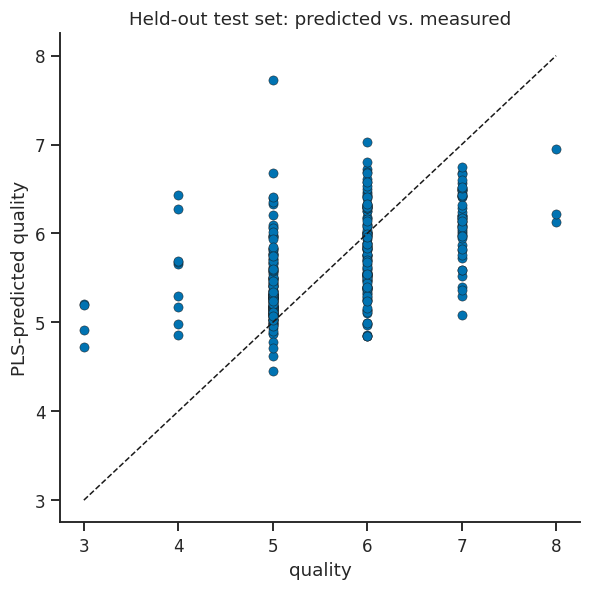

In [15]:
# TODO: report test-set RMSE and/or R^2, and a predicted-vs-observed plot
# (include the y=x identity line for reference)


# ── Fit final PLS model on the full training set, evaluate ONCE on the held-out test set ──
pls_final = PLSRegression(n_components=best_nc, scale=True).fit(X_train, y_train)
y_pred_test = pls_final.predict(X_test).ravel()
r2_test = r2_score(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
print(f'PLS test-set R2:   {r2_test:.3f}')
print(f'PLS test-set RMSE: {rmse_test:.3f}')

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(y_test, y_pred_test, color=sns.color_palette('colorblind')[0], edgecolor='k', linewidth=0.3)
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
ax.plot(lims, lims, 'k--', lw=1)
ax.set_xlabel('quality'); ax.set_ylabel('PLS-predicted quality')
ax.set_title('Held-out test set: predicted vs. measured')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()



### LDA (quality binned into categories)

In [16]:
# TODO: define your quality bins explicitly here (e.g. low / medium / high).
# State your bin edges and reasoning on the answer sheet (Checkpoint 3b) --
# this is a real modelling decision, not a formality.
# Check the resulting class sizes: are they balanced?

labels1 = []
for yi in y_train:
  if yi in (3,4):
    labels1.append('low')

  elif yi in (5,6):
    labels1.append('medium')

  else:
    labels1.append('high')
labels2 = []
for yi in y_test:
  if yi in (3,4):
    labels2.append('low')

  elif yi in (5,6):
    labels2.append('medium')

  else:
    labels2.append('high')

#print(labels.count('low'))
#print(labels.count('medium'))
#print(labels.count('high'))
print(len(labels1))

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=0)
print(f'Train: {X_train.shape[0]}, Test: {X_test.shape[0]}')

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.fit_transform(X_test)


1019
Train: 1019, Test: 340


In [17]:
# TODO: train/test split, then fit LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
lda_scores = lda.fit_transform(x_train_scaled, y_train)
for i, ev in enumerate(lda.explained_variance_ratio_, 1):
  print(f'  LD{i}: {ev*100: 1f}%')

  LD1:  86.027968%
  LD2:  8.980306%
  LD3:  3.351291%
  LD4:  1.012567%
  LD5:  0.627868%


              precision    recall  f1-score   support

         low       0.33      0.08      0.12        13
      medium       0.83      0.93      0.88       272
        high       0.39      0.24      0.30        55

    accuracy                           0.78       340
   macro avg       0.52      0.41      0.43       340
weighted avg       0.74      0.78      0.75       340



"\nmajority = []\nfor i in range(len(y_pred_list)):\n  majority.append('medium')\n\ncm = confusion_matrix(labels2, majority, labels = class_labels)\ndisp = ConfusionMatrixDisplay(cm)\ndisp.plot()\nplt.show\nprint(classification_report(labels2, majority, labels=class_labels, target_names =[str(x) for x in class_labels]))\n"

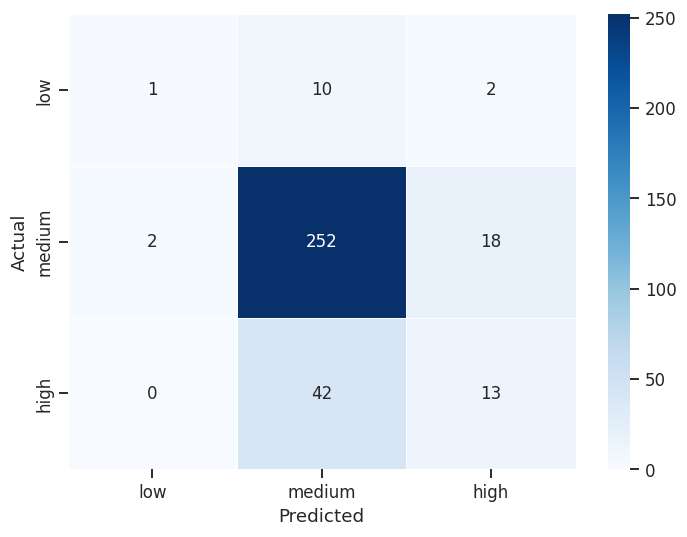

In [19]:
# TODO: report a confusion matrix (ConfusionMatrixDisplay) and per-class
# accuracy on the TEST set -- accuracy alone is not enough here
from sklearn.metrics import classification_report
y_pred = lda.predict(x_test_scaled)
y_pred_list = []
for i in y_pred:
  if i in (3,4):
    y_pred_list.append('low')

  elif i in (5,6):
    y_pred_list.append('medium')

  else:
    y_pred_list.append('high')

class_labels = ['low','medium','high']
cm = confusion_matrix(labels2, y_pred_list, labels = class_labels)
fig, ax = plt.subplots()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels,
            linewidths=0.5, ax=ax)

#disp = ConfusionMatrixDisplay(cm)
#disp.plot()
plt.tight_layout()
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.show
print(classification_report(labels2, y_pred_list, labels=class_labels, target_names =[str(x) for x in class_labels]))


#to test every guess is majority..... 0%, 80%, 0% correct.
'''
majority = []
for i in range(len(y_pred_list)):
  majority.append('medium')

cm = confusion_matrix(labels2, majority, labels = class_labels)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show
print(classification_report(labels2, majority, labels=class_labels, target_names =[str(x) for x in class_labels]))
'''


In [20]:
# TODO: Checkpoint 3c/3d groundwork -- pull out and compare the top
# variables from both models (PLS coefficients vs. LDA discriminant
# loadings). Your written comparison goes on the answer sheet.

lda_coef = lda.coef_
pls_coef = pls.coef_
print(lda_coef[0].round(3))
print('')
print(pls.x_loadings_[0].round(3))




[ 1.305  2.821  1.834  0.245  0.554  0.555 -1.102 -0.943  1.44  -0.39
 -1.752]

[ 0.164  0.53  -0.491 -0.071  0.102 -0.106 -0.219 -0.367  0.876  0.167
  0.034]


---
## Step 4 — Does It Transfer? White Wine (3:00–3:45)

Repeat the analysis on `winequality-white.csv` and check whether your
Step 2/3 findings are genuine wine chemistry or specific to the red-wine
dataset. You only need to redo **one** of PLS/LDA here, not both.

- [ ] Curate the white wine data the same way as Step 1 (its own duplicate/quality-distribution answer will differ from red)
- [ ] Redo the PCA from Step 2 on white wine (→ **Checkpoint 4a**)
- [ ] Redo ONE of your two Step 3 models on white wine (→ **Checkpoint 4b**)

In [32]:
# TODO: load winequality-white.csv, curate it the same way as Step 1
# (missing values, duplicates, quality distribution)
df = pd.read_csv('winequality-white.csv', sep=';')
print(df.shape)
df.head()
df.isnull().sum()
print(df.duplicated().sum())
df = df.drop_duplicates()
print(df.duplicated().sum())
print(df['quality'].value_counts().sort_index())




(4898, 12)
937
0
quality
3      20
4     153
5    1175
6    1788
7     689
8     131
9       5
Name: count, dtype: int64


0.8109999999999998


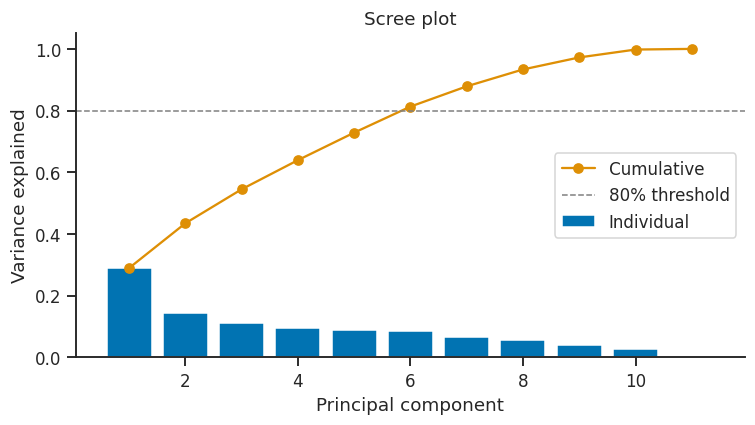

In [33]:
# TODO: standardise the white-wine predictors and redo the PCA + scree/
# score/loading plots from Step 2. Compare PC1's top-loading variables to
# what you found for red wine (Checkpoint 2c) -- write the comparison on
# the answer sheet (Checkpoint 4a).

y = df['quality']

x_df = df.drop('quality', axis=1)

x = StandardScaler().fit_transform(x_df)

X_scaled_sklearn = StandardScaler().fit_transform(x)
pca_sklearn = PCA()
scores_sklearn = pca_sklearn.fit_transform(X_scaled_sklearn)
print(pca_sklearn.explained_variance_ratio_.round(3)[0:6].sum())


fig, ax = plt.subplots(figsize=(7, 4))
n_show = 11
ax.bar(range(1, n_show+1), pca_sklearn.explained_variance_ratio_[:n_show],
       color=sns.color_palette('colorblind')[0], label='Individual')
ax.plot(range(1, n_show+1), np.cumsum(pca_sklearn.explained_variance_ratio_[:n_show]),
        'o-', color=sns.color_palette('colorblind')[1], label='Cumulative')
ax.axhline(0.80, color='gray', ls='--', lw=1, label='80% threshold')
ax.set_xlabel('Principal component'); ax.set_ylabel('Variance explained')
ax.set_title('Scree plot')
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

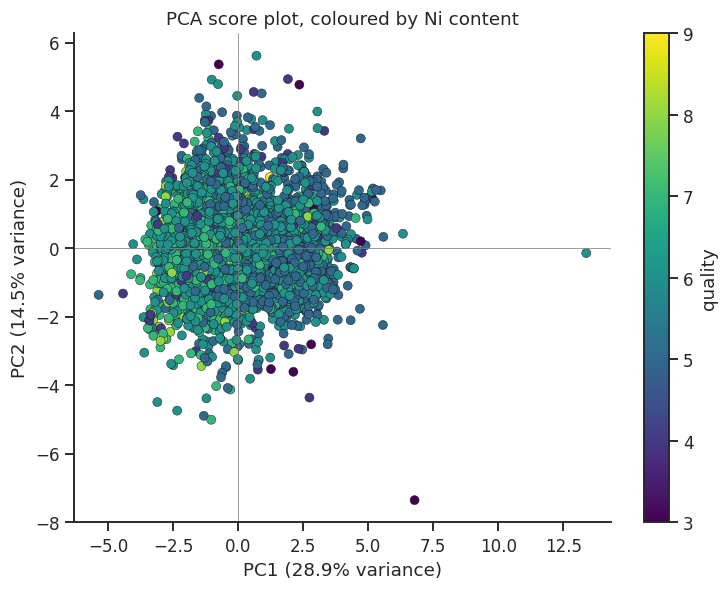

In [34]:
df_scores = pd.DataFrame(scores_sklearn[:, :3], columns=['PC1', 'PC2', 'PC3'])
df_scores['quality'] = df['quality'].values

fig, ax = plt.subplots(figsize=(7, 5.5))
sc = ax.scatter(df_scores['PC1'], df_scores['PC2'], c=df_scores['quality'],
                 cmap='viridis', s=35, edgecolor='k', linewidth=0.3)
ax.set_xlabel(f'PC1 ({pca_sklearn.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca_sklearn.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('PCA score plot, coloured by Ni content')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
plt.colorbar(sc, label='quality')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

                       PC1   PC2
alcohol              -0.43  0.05
pH                   -0.11 -0.58
volatile acidity      0.03 -0.06
sulphates             0.05 -0.19
citric acid           0.15  0.38
fixed acidity         0.15  0.60
chlorides             0.21  0.03
free sulfur dioxide   0.31 -0.26
residual sugar        0.42 -0.02
total sulfur dioxide  0.42 -0.23
density               0.51 -0.01


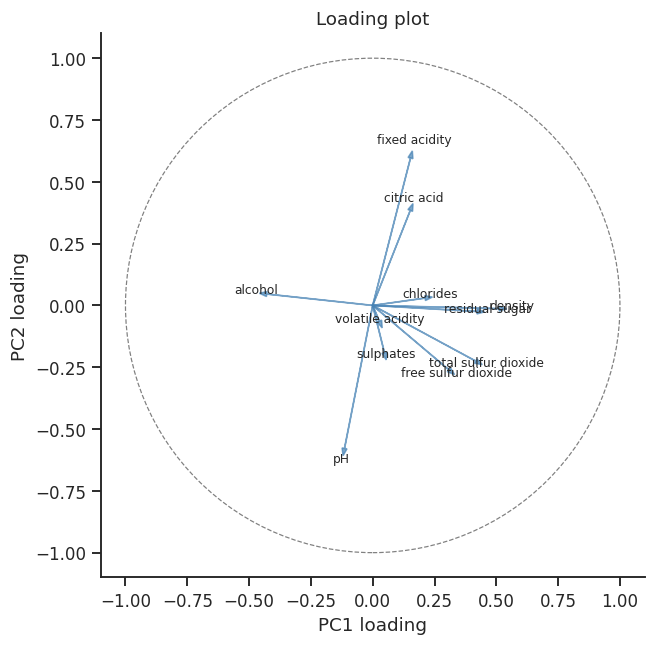

In [36]:
loadings_df = pd.DataFrame(pca_sklearn.components_[:2].T, index = x_df.columns, columns=['PC1', 'PC2'])
print(loadings_df.round(2).sort_values('PC1'))

fig, ax = plt.subplots(figsize=(7, 6))
for var in x_df.columns:
    x_co, y_co = loadings_df.loc[var, 'PC1'], loadings_df.loc[var, 'PC2']
    ax.arrow(0, 0, x_co, y_co, head_width=0.02, color='steelblue', alpha=0.7)
    ax.text(x_co*1.1, y_co*1.1, var, fontsize=8, ha='center')
circle = plt.Circle((0, 0), 1, fill=False, color='gray', ls='--', lw=0.8)
ax.add_patch(circle)
ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
ax.set_xlabel('PC1 loading'); ax.set_ylabel('PC2 loading')
ax.set_aspect('equal')
ax.set_title('Loading plot')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

In [ ]:
# TODO: redo ONE of your two Step 3 models (PLS or LDA -- your choice) on
# white wine, same methodology as before. Compare validated performance and
# top variables to your red-wine result (Checkpoint 3a/3b/3d) -- write the
# comparison on the answer sheet (Checkpoint 4b).

---
## Wrap-up (3:45–4:00)

- [ ] Finalise your answer sheet (Checkpoints 1a–4b)

Hand in **this notebook** + your **answer sheet** — no separate report.